<!-- # DS701: Tools for Data Science - Midterm Challenge -- Sports

In this challenge, you will build a systematic analysis of LALIGA shot data from seasons 2015-16 through 2024-25.

### Objectives:
1. **Setup and Loade** the LALIGA shots dataset
2. **Exploratory Data Analysis (EDA)** - understand patterns, distributions, and relationships
3. **Clustering Analysis** - identify player archetypes based on shooting patterns
4. **Predictive Modeling** - build models to predict goal probability (excluding xG feature)
5. **Model Comparison** - compare our predictions with the existing xG metric
6. **Kaggle Submission** - prepare a submission for the Kaggle competition
7. **Summary and Conclusions** - summarize your findings and conclusions

You can use as many markdown and code cells as you want in your solutions. -->


---
## 1. Setup and Data Loading

In [84]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import seaborn as sns
from scipy import stats

import matplotlib as mt
from matplotlib import ticker

# Set visualization style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

# Set random seed for reproducibility
np.random.seed(42)

# Display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', lambda x: '%.4f' % x)

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


In [85]:
# Load the dataset
df = pd.read_csv('laliga_shots_train.csv')

print(f"Dataset loaded successfully!")
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\nFirst few rows:")
df.head()

Dataset loaded successfully!
Shape: 72,116 rows × 19 columns

First few rows:


,id,minute,result,X,Y,player,h_a,player_id,situation,season,shotType,match_id,h_team,a_team,h_goals,a_goals,date,player_assisted,lastAction
0,297163,44,Goal,0.8960,0.6270,Borja Bastón,a,1701,SetPiece,2018,RightFoot,10301,Athletic Club,Alaves,1,1,2019-04-27 12:00:00,NaN,Rebound
1,606888,49,MissedShots,0.8610,0.7230,Aimar Oroz,a,8424,OpenPlay,2024,RightFoot,27150,Espanyol,Osasuna,0,0,2024-12-14 13:00:00,Ante Budimir,Pass
2,140398,29,SavedShot,0.9250,0.3240,Gerard Moreno,h,2120,OpenPlay,2016,LeftFoot,3991,Espanyol,Las Palmas,4,3,2017-03-10 19:45:00,Felipe Caicedo,Throughball
3,336585,42,SavedShot,0.4400,0.5300,Youssef En-Nesyri,h,5169,OpenPlay,2019,LeftFoot,12177,Leganes,Celta Vigo,3,2,2019-12-08 17:30:00,Rubén Pérez,BallRecovery
4,575017,30,BlockedShot,0.8930,0.4570,Sergio Camello,h,7528,OpenPlay,2023,RightFoot,23004,Rayo Vallecano,Osasuna,2,1,2024-04-20 14:15:00,Jorge De Frutos,Cross


In [86]:
# Dataset overview
print("=" * 80)
print("DATASET OVERVIEW")
print("=" * 80)

df.info()

DATASET OVERVIEW
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72116 entries, 0 to 72115
Data columns (total 19 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               72116 non-null  int64  
 1   minute           72116 non-null  int64  
 2   result           72116 non-null  object 
 3   X                72116 non-null  float64
 4   Y                72116 non-null  float64
 5   player           72116 non-null  object 
 6   h_a              72116 non-null  object 
 7   player_id        72116 non-null  int64  
 8   situation        72116 non-null  object 
 9   season           72116 non-null  int64  
 10  shotType         72116 non-null  object 
 11  match_id         72116 non-null  int64  
 12  h_team           72116 non-null  object 
 13  a_team           72116 non-null  object 
 14  h_goals          72116 non-null  int64  
 15  a_goals          72116 non-null  int64  
 16  date             72116 non-null  object 


In [87]:
# Check for missing values
print("\nMissing Values:")
missing_df = pd.DataFrame({
    'Column': df.columns,
    'Missing_Count': df.isnull().sum().values,
    'Missing_Percentage': (df.isnull().sum().values / len(df) * 100).round(2)
})
missing_df = missing_df[missing_df['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)
print(missing_df.to_string(index=False))

if len(missing_df) == 0:
    print("No missing values in required columns!")


Missing Values:
         Column  Missing_Count  Missing_Percentage
player_assisted          19310             26.7800
     lastAction           8643             11.9800


## Explanation of the columns


| Column | Description |
|--------|-------------|
| **id** | Unique shot identifier |
| **minute** | Minute of the match when shot occurred. Regularly two 45-minute halves. |
| **result** | Shot outcome (Goal, SavedShot, MissedShots, BlockedShot) |
| **X** | X-coordinate of shot location on pitch, where X = 0 is the defensive end (own goal) and X = 1 is the attacking end (opponent goal) |
| **Y** | Y-coordinate of shot location on pitch |
| **player** | Name of player taking the shot |
| **h_a** | Home ('h') or Away ('a') team indicator |
| **player_id** | Unique player identifier |
| **situation** | Match situation (OpenPlay, FromCorner, SetPiece, etc.) |
| **season** | Season year |
| **shotType** | Type of shot (RightFoot, LeftFoot, Head, OtherBodyPart) |
| **match_id** | Match identifier |
| **h_team** | Home team name |
| **a_team** | Away team name |
| **h_goals** | Home team goals at time of shot |
| **a_goals** | Away team goals at time of shot |
| **date** | Match date |
| **player_assisted** | Player who assisted |
| **lastAction** | Last action before shot |


---

#### Load the Test Set

We'll also need to load the test set so we can predict the results for it and
submit it for evaluation.

In [88]:
# Load the test set
df_test = pd.read_csv('laliga_shots_test_no_result.csv')

print(f"Dataset loaded successfully!")
print(f"Shape: {df_test.shape[0]:,} rows × {df_test.shape[1]} columns")
print(f"\nFirst few rows:")
df_test.head()

Dataset loaded successfully!
Shape: 18,029 rows × 18 columns

First few rows:


,id,minute,X,Y,player,h_a,player_id,situation,season,shotType,match_id,h_team,a_team,h_goals,a_goals,date,player_assisted,lastAction
0,444146,63,0.9800,0.5430,Isi Palazón,a,9812,FromCorner,2021,LeftFoot,17284,Valencia,Rayo Vallecano,1,1,2021-11-27 15:15:00,NaN,Rebound
1,281129,31,0.9160,0.3710,Giannelli Imbula,a,861,OpenPlay,2018,LeftFoot,10183,Espanyol,Rayo Vallecano,2,1,2019-02-09 17:30:00,NaN,NaN
2,455491,26,0.8560,0.5460,Gerard Piqué,a,2092,FromCorner,2021,Head,17346,Alaves,Barcelona,0,1,2022-01-23 20:00:00,Pedri,Aerial
3,213542,36,0.8640,0.3850,Daniel Torres,a,5048,OpenPlay,2017,RightFoot,8232,Malaga,Alaves,0,3,2018-05-06 11:00:00,NaN,TakeOn
4,195341,37,0.8800,0.4160,Simone Zaza,a,1642,SetPiece,2017,LeftFoot,8098,Atletico Madrid,Valencia,1,0,2018-02-04 19:45:00,José Gayá,Cross


In [89]:
# Test set overview
print("=" * 80)
print("TEST SET OVERVIEW")
print("=" * 80)

df_test.info()

TEST SET OVERVIEW
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18029 entries, 0 to 18028
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               18029 non-null  int64  
 1   minute           18029 non-null  int64  
 2   X                18029 non-null  float64
 3   Y                18029 non-null  float64
 4   player           18029 non-null  object 
 5   h_a              18029 non-null  object 
 6   player_id        18029 non-null  int64  
 7   situation        18029 non-null  object 
 8   season           18029 non-null  int64  
 9   shotType         18029 non-null  object 
 10  match_id         18029 non-null  int64  
 11  h_team           18029 non-null  object 
 12  a_team           18029 non-null  object 
 13  h_goals          18029 non-null  int64  
 14  a_goals          18029 non-null  int64  
 15  date             18029 non-null  object 
 16  player_assisted  13150 non-null  object 

---
## 2. Exploratory Data Analysis (EDA) (35 total points)

### 2.1 Target Variable Analysis - Shot Results (5 points)

Analyze the distribution of shot 'results' and:

1. print as a table with columns 'Result', 'Count', and 'Percentage'. (5 points)
2. Show a bar plot of the distribution of 'result' categories. (5 points)   
3. Show a pie chart of the distribution of 'result' categories. (5 points)
4. Calculate the goal conversion rate. (5 points)

In [90]:
# 1. print as a table with columns 'Result', 'Count', and 'Percentage'

df_res = df.groupby(['result']).size().reset_index()

df_res.rename(columns={'result': 'Result', 0: 'Count'}, inplace= True)

df_res['Percentage'] = df_res['Count'].apply(lambda x: x/(df_res['Count'].sum()) * 100).round(2)

print(df_res)

        Result  Count  Percentage
0  BlockedShot  17218     23.8800
1         Goal   7778     10.7900
2  MissedShots  28420     39.4100
3      OwnGoal    218      0.3000
4    SavedShot  17018     23.6000
5   ShotOnPost   1464      2.0300


Text(0.5, 1.0, 'Distribution of Play Results')

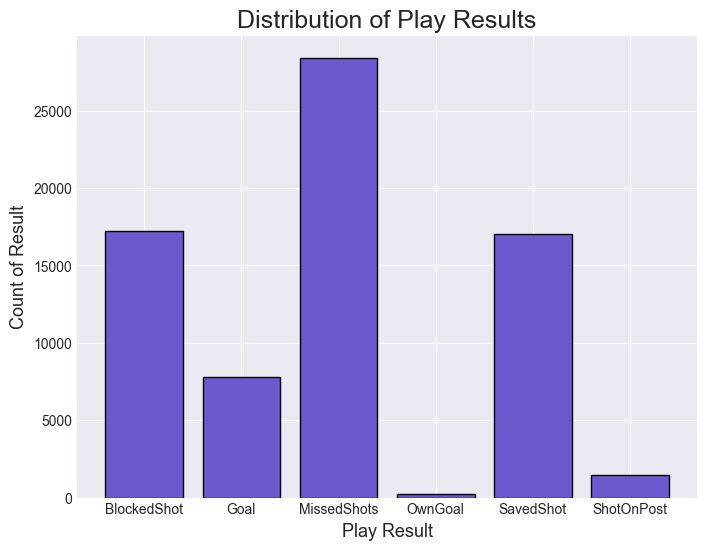

In [91]:
# 2. Show a bar plot of the distribution of 'result' categories

plt.figure(figsize = (8,6))
plt.bar(df_res['Result'], df_res['Count'], facecolor = 'slateblue', edgecolor='black')
plt.xlabel('Play Result', fontsize=13)
plt.ylabel('Count of Result', fontsize=13)
plt.title('Distribution of Play Results', fontsize=18)

Text(0.5, 1.3, 'Distribution of Play Results')

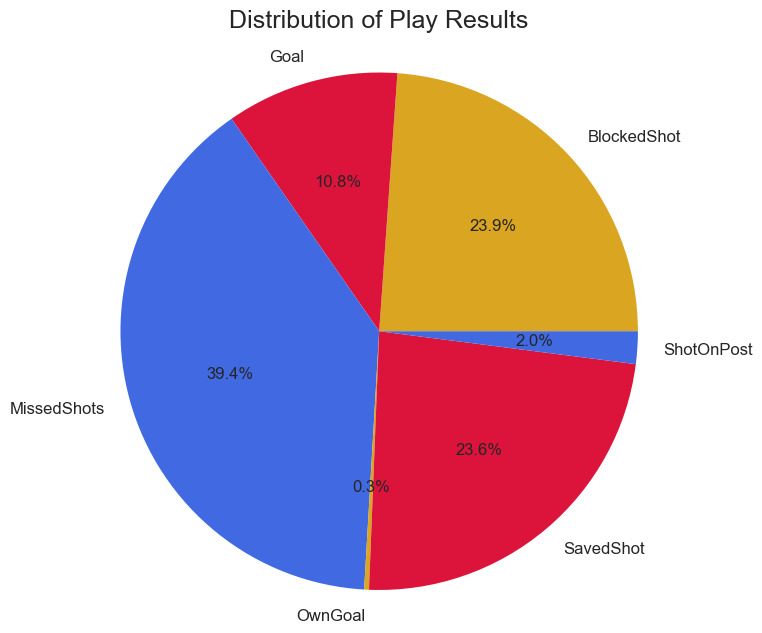

In [92]:
# 3. Show a pie chart of the distribution of 'result' categories
cs = ['goldenrod', 'crimson', 'royalblue']

fig, ax = plt.subplots()
ax.pie(df_res['Percentage'], labels=df_res['Result'], radius= 1.75, autopct='%1.1f%%', textprops={'size': 'larger'},colors= cs)
ax.set_title('Distribution of Play Results', y= 1.3, fontsize=18)

In [93]:
# 4. Calculate the goal  rate
# goal  rate = (Goals ÷ Total shots) × 100 total, use the df_res database

# total of all shots
total = sum(x for x in df_res['Count'])

goal_conv = df_res.loc[(df_res.Result == 'Goal')]['Count'][1]/total

print(f"Goal  Rate: {goal_conv:.4f}")

Goal  Rate: 0.1079


### 2.2 Numerical Features Analysis (5 points)

For the numerical features, calculate the following:
1. Statistical summary of the numerical features. (5 points)
2. Distribution plots for the key numerical features. (5 points)


In [94]:
df.describe()

,id,minute,X,Y,player_id,season,match_id,h_goals,a_goals
count,72116.0000,72116.0000,72116.0000,72116.0000,72116.0000,72116.0000,72116.0000,72116.0000,72116.0000
mean,355666.1304,49.0744,0.8469,0.5049,4427.2750,2019.5004,13675.4030,1.5511,1.1950
std,173622.9932,26.7468,0.0918,0.1298,3038.3767,2.8973,7887.4379,1.3204,1.1472
min,83973.0000,0.0000,0.0040,0.0030,44.0000,2015.0000,1399.0000,0.0000,0.0000
25%,186912.7500,27.0000,0.7850,0.4150,2229.0000,2017.0000,8051.0000,1.0000,0.0000
50%,372120.5000,49.0000,0.8680,0.5030,2519.0000,2019.0000,12391.0000,1.0000,1.0000
75%,510286.2500,72.0000,0.9100,0.5970,6917.0000,2022.0000,19178.0000,2.0000,2.0000
max,636609.0000,106.0000,0.9990,0.9950,13629.0000,2024.0000,27361.0000,10.0000,8.0000


Text(0, 0.5, 'Games Played')

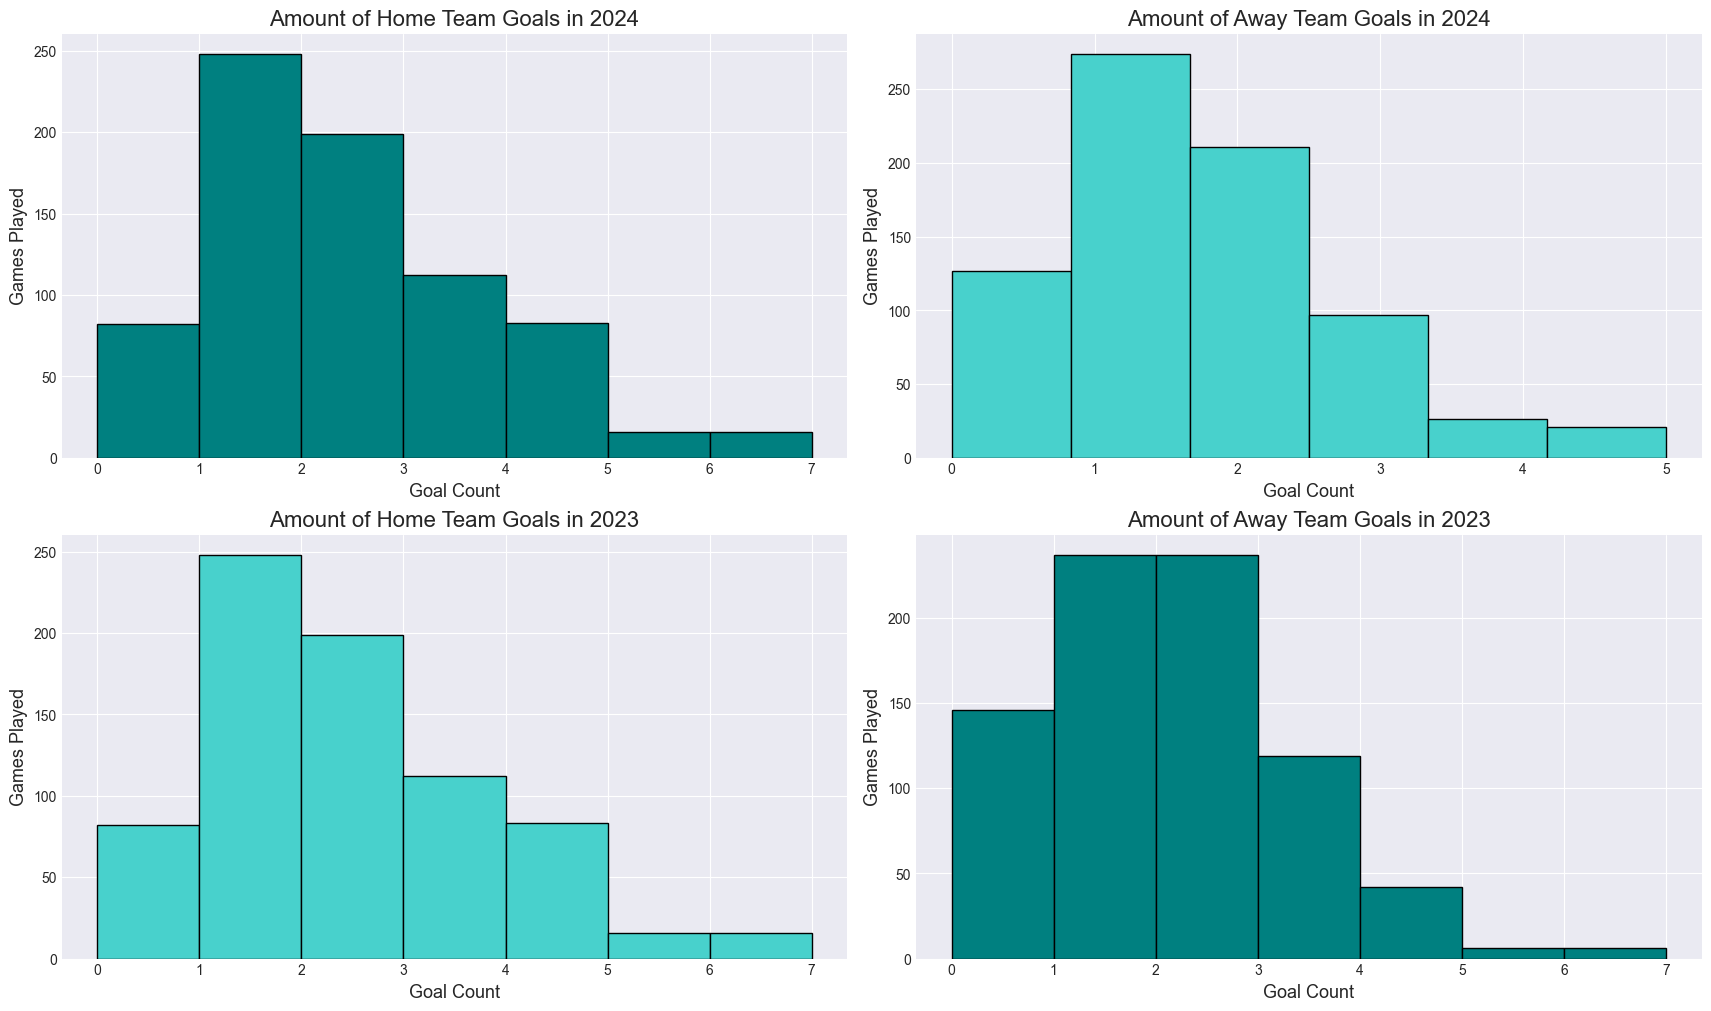

In [95]:
# distribution of home/ away goals by all matches 2023 and 2024

a_goals = df[['season', 'a_goals', 'result']]
a_goals = a_goals[a_goals['result'] == 'Goal']

h_goals = df[['season', 'h_goals', 'result']]
h_goals = h_goals[h_goals['result'] == 'Goal']

a_goals_24 = a_goals[a_goals['season'] == 2024]
a_goals_24.drop(columns = ['season'], inplace= True)

a_goals_23 = a_goals[a_goals['season'] == 2023]
a_goals_23.drop(columns = ['season'], inplace= True)

h_goals_24 = h_goals[h_goals['season'] == 2024]
h_goals_24.drop(columns = ['season'], inplace= True)

h_goals_23 = h_goals[h_goals['season'] == 2023]
h_goals_23.drop(columns = ['season'], inplace= True)

fig, axs = plt.subplots(ncols=2, nrows=2, figsize=(17, 10), layout="constrained")

axs[0][0].hist(h_goals_24['h_goals'], bins = 7, edgecolor='black', facecolor = 'teal')
axs[0][0].set_title('Amount of Home Team Goals in 2024', fontsize= 16)
axs[0][0].set_xlabel('Goal Count', fontsize= 13)
axs[0][0].set_ylabel('Games Played', fontsize= 13)

axs[0][1].hist(a_goals_24['a_goals'], bins = 6, edgecolor='black', facecolor = 'mediumturquoise')
axs[0][1].set_title('Amount of Away Team Goals in 2024', fontsize= 16)
axs[0][1].set_xlabel('Goal Count', fontsize= 13)
axs[0][1].set_ylabel('Games Played', fontsize= 13)

axs[1][0].hist(h_goals_24['h_goals'], bins = 7, edgecolor='black', facecolor = 'mediumturquoise')
axs[1][0].set_title('Amount of Home Team Goals in 2023', fontsize= 16)
axs[1][0].set_xlabel('Goal Count', fontsize= 13)
axs[1][0].set_ylabel('Games Played', fontsize= 13)

axs[1][1].hist(a_goals_23['a_goals'], bins = 7, edgecolor='black', facecolor = 'teal')
axs[1][1].set_title('Amount of Away Team Goals in 2023', fontsize= 16)
axs[1][1].set_xlabel('Goal Count', fontsize= 13)
axs[1][1].set_ylabel('Games Played', fontsize= 13)

Text(0, 0.5, 'Goals')

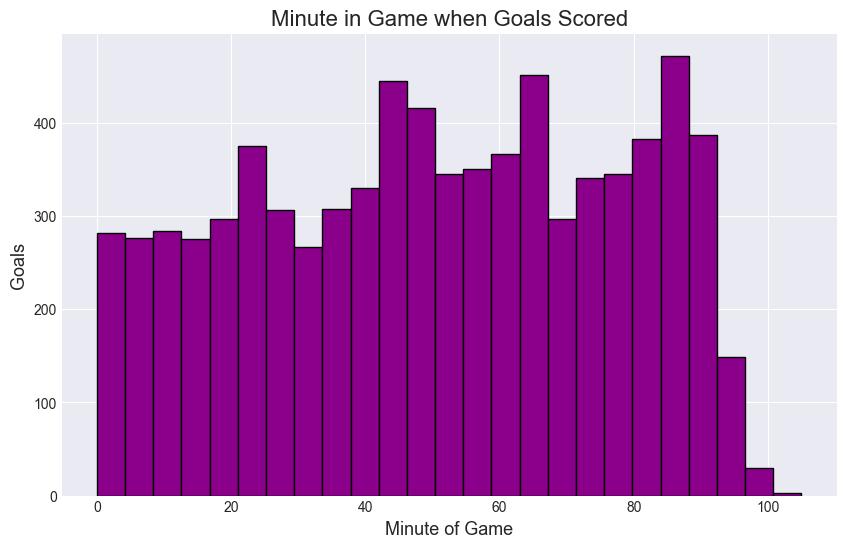

In [96]:
# distribution of minute of events
mins = df[['minute', 'result']]
mins = mins[mins['result'] == 'Goal']

plt.figure(figsize=(10, 6))
plt.hist(mins['minute'], bins = 25, edgecolor='black', facecolor = 'darkmagenta')
plt.title('Minute in Game when Goals Scored', fontsize= 16)
plt.xlabel('Minute of Game', fontsize= 13)
plt.ylabel('Goals', fontsize= 13)

### 2.3 Shot Location Analysis (X, Y Coordinates) (5 points)

Create a scatter plot of shot locations colored by result. (10 points)

Calculate the average X and Y coordinates for goals. (5 points)

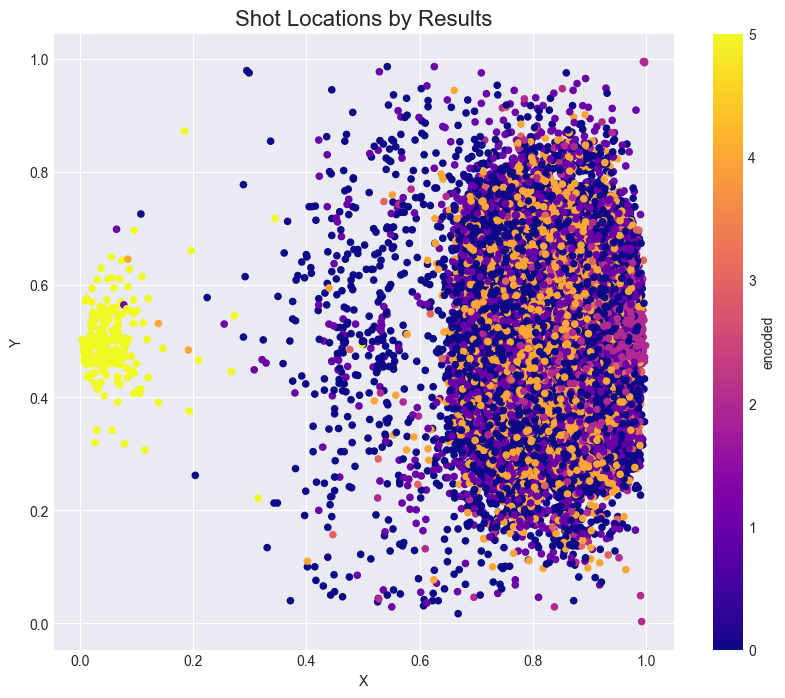

In [97]:
# color by result, group is the result,
# encode results for graph, decode for legend (factorize function encoded, uniques fac)

xy = df[['result', 'X', 'Y']]

opts = set(xy['result'].values) # get all options for groups, set to remove dups
opts = list(opts)
nums = [opts.index(a) for a in opts]

xy['encoded'] = xy['result'].apply(lambda a: opts.index(a)) # adds encoded column

xy.plot('X', 'Y', kind = 'scatter', c = 'encoded', colormap='plasma', figsize =(10,8))

plt.title('Shot Locations by Results', fontsize= 16)
# plt.legend([opts])
# plt.legend()
plt.show()

In [98]:
# get average X & Y for all goals

g_avg = xy[xy['result'] == 'Goal']

x_avg = g_avg.agg({'X': 'mean'}).values[0]
y_avg = g_avg.agg({'Y': 'mean'}).values[0]

print(f"Average X Coord for all Goals: {x_avg:.4f}")
print(f"Average Y Coord for all Goals: {y_avg:.4f}")

Average X Coord for all Goals: 0.8976
Average Y Coord for all Goals: 0.5016


### 2.4 Categorical Features Analysis (5 points)

Show the bar plots for each of the categorical features. (10 points)

Text(0, 0.5, 'Goals')

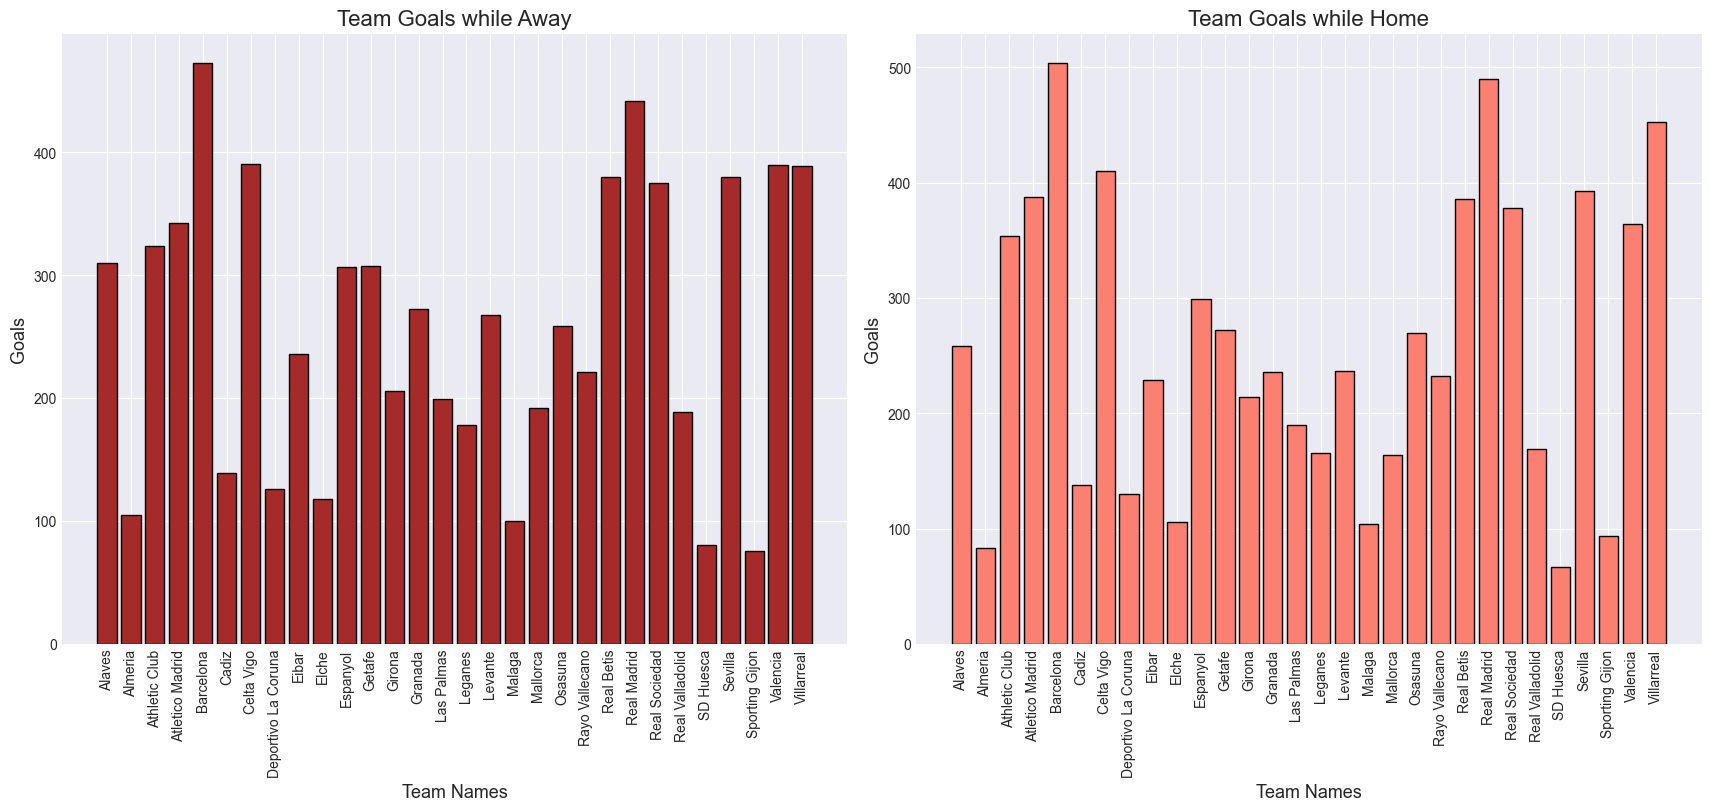

In [99]:
# home team/ away team play result goals amount

ha_teams = df[['h_team', 'a_team', 'result']]

a = ha_teams.groupby(['a_team', 'result']).size().reset_index()
a.rename(columns={0: 'count'}, inplace= True)
a = a[a['result'] == 'Goal']

h = ha_teams.groupby(['h_team', 'result']).size().reset_index()
h.rename(columns={0: 'count'}, inplace= True)
h = h[h['result'] == 'Goal']

fig, axs = plt.subplots(ncols=2, nrows=1, figsize=(17, 8), layout="constrained")

axs[0].bar(x = a['a_team'], height = a['count'], edgecolor='black', facecolor = 'brown')
axs[0].set_title('Team Goals while Away', fontsize= 16)
axs[0].set_xlabel('Team Names', fontsize= 13)
axs[0].tick_params(axis='x', labelrotation=90)
axs[0].set_ylabel('Goals', fontsize= 13)

axs[1].bar(x = h['h_team'], height = h['count'], edgecolor='black', facecolor = 'salmon')
axs[1].set_title('Team Goals while Home', fontsize= 16)
axs[1].set_xlabel('Team Names', fontsize= 13)
axs[1].tick_params(axis='x', labelrotation=90)
axs[1].set_ylabel('Goals', fontsize= 13)

Text(0, 0.5, 'Count of Goals')

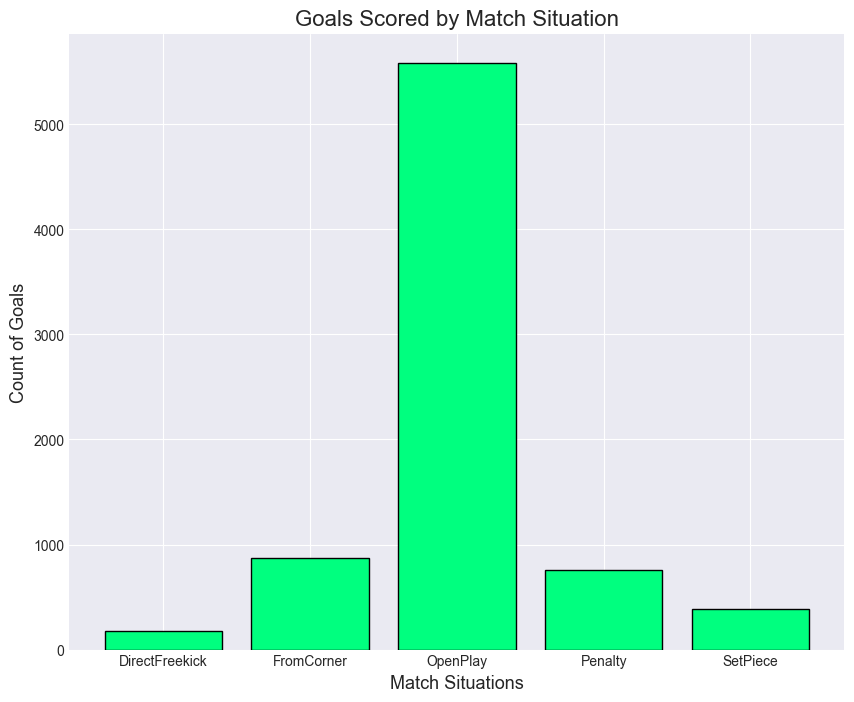

In [100]:
# count of match situations at goal

sit_goal = df.groupby(['situation', 'result']).size().reset_index()
sit_goal = sit_goal[sit_goal['result'] == 'Goal']
sit_goal.rename(columns = {0: 'count'}, inplace= True)

plt.figure(figsize= (10, 8))
plt.bar(x = sit_goal['situation'], height = sit_goal['count'], edgecolor='black', facecolor = 'springgreen')
plt.title('Goals Scored by Match Situation', fontsize= 16)
plt.xlabel('Match Situations', fontsize= 13)
plt.ylabel('Count of Goals', fontsize= 13)


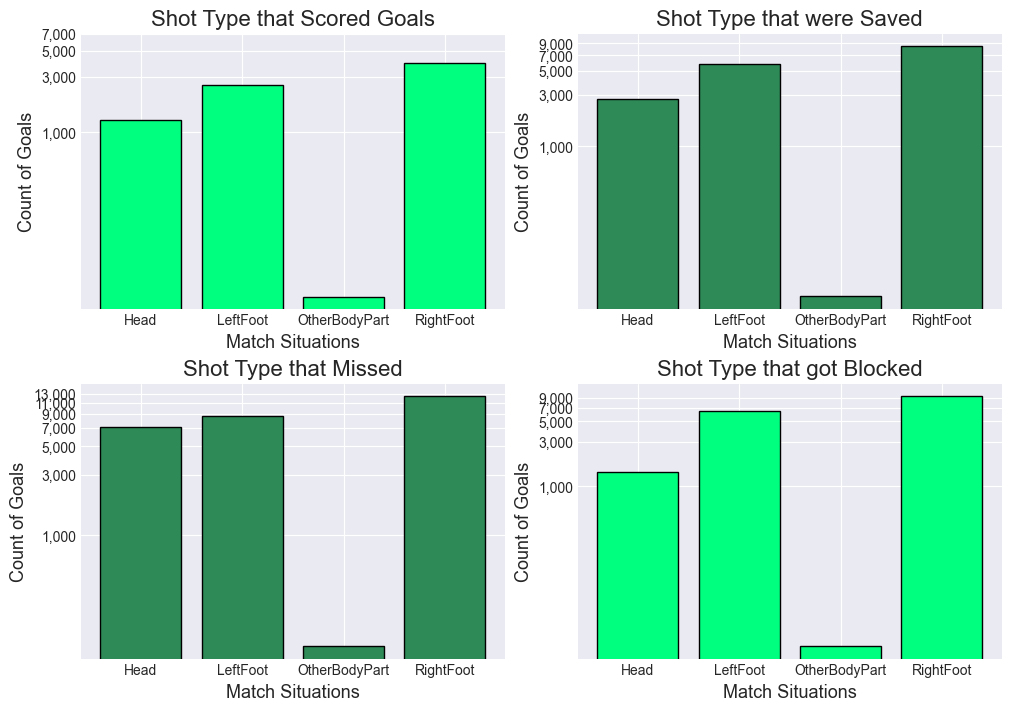

In [101]:
# shot type count for games won
# (Goal, SavedShot, MissedShots, BlockedShot)

shot_goal = df.groupby(['shotType', 'result']).size().reset_index()
shot_goal = shot_goal[shot_goal['result'] == 'Goal']
shot_goal.rename(columns = {0: 'count'}, inplace= True)

shot_saved = df.groupby(['shotType', 'result']).size().reset_index()
shot_saved = shot_saved[shot_saved['result'] == 'SavedShot']
shot_saved.rename(columns = {0: 'count'}, inplace= True)

shot_miss = df.groupby(['shotType', 'result']).size().reset_index()
shot_miss = shot_miss[shot_miss['result'] == 'MissedShots']
shot_miss.rename(columns = {0: 'count'}, inplace= True)

shot_block = df.groupby(['shotType', 'result']).size().reset_index()
shot_block = shot_block[shot_block['result'] == 'BlockedShot']
shot_block.rename(columns = {0: 'count'}, inplace= True)

fig, axs = plt.subplots(ncols=2, nrows=2, figsize=(10, 7), layout="constrained")

axs[0][0].bar(x = shot_goal['shotType'], height = shot_goal['count'], edgecolor='black', facecolor = 'springgreen')
axs[0][0].set_title('Shot Type that Scored Goals', fontsize= 16)
axs[0][0].set_xlabel('Match Situations', fontsize= 13)
axs[0][0].set_ylabel('Count of Goals', fontsize= 13)
axs[0][0].set_yscale('log', base = 2)
axs[0][0].get_yaxis().set_major_formatter(mt.ticker.FuncFormatter(lambda x, p: format(int(x), ',')))
axs[0][0].set_yticks(np.arange(1000, 8000, 2000))

axs[0][1].bar(x = shot_saved['shotType'], height = shot_saved['count'], edgecolor='black', facecolor = 'seagreen')
axs[0][1].set_title('Shot Type that were Saved', fontsize= 16)
axs[0][1].set_xlabel('Match Situations', fontsize= 13)
axs[0][1].set_ylabel('Count of Goals', fontsize= 13)
axs[0][1].set_yscale('log', base = 2)
axs[0][1].get_yaxis().set_major_formatter(mt.ticker.FuncFormatter(lambda x, p: format(int(x), ',')))
axs[0][1].set_yticks(np.arange(1000, 10000, 2000))

axs[1][0].bar(x = shot_miss['shotType'], height = shot_miss['count'], edgecolor='black', facecolor = 'seagreen')
axs[1][0].set_title('Shot Type that Missed', fontsize= 16)
axs[1][0].set_xlabel('Match Situations', fontsize= 13)
axs[1][0].set_ylabel('Count of Goals', fontsize= 13)
axs[1][0].set_yscale('log', base = 2)
axs[1][0].get_yaxis().set_major_formatter(mt.ticker.FuncFormatter(lambda x, p: format(int(x), ',')))
axs[1][0].set_yticks(np.arange(1000, 14000, 2000))

axs[1][1].bar(x = shot_block['shotType'], height = shot_block['count'], edgecolor='black', facecolor = 'springgreen')
axs[1][1].set_title('Shot Type that got Blocked', fontsize= 16)
axs[1][1].set_xlabel('Match Situations', fontsize= 13)
axs[1][1].set_ylabel('Count of Goals', fontsize= 13)
axs[1][1].set_yscale('log', base = 2)
axs[1][1].get_yaxis().set_major_formatter(mt.ticker.FuncFormatter(lambda x, p: format(int(x), ',')))
axs[1][1].set_yticks(np.arange(1000, 11000, 2000))


### 2.5 Goal Conversion by Categorical Features (5 points)

Calculate the goal conversion rate by each of the categorical features, 'situation', 'shotType', and 'h_a'. (10 points)
* Display the results in a table with columns '<Category>', 'Total Shots', 'Goal Rate (%)'.

Display the results in bar plots. (5 points)

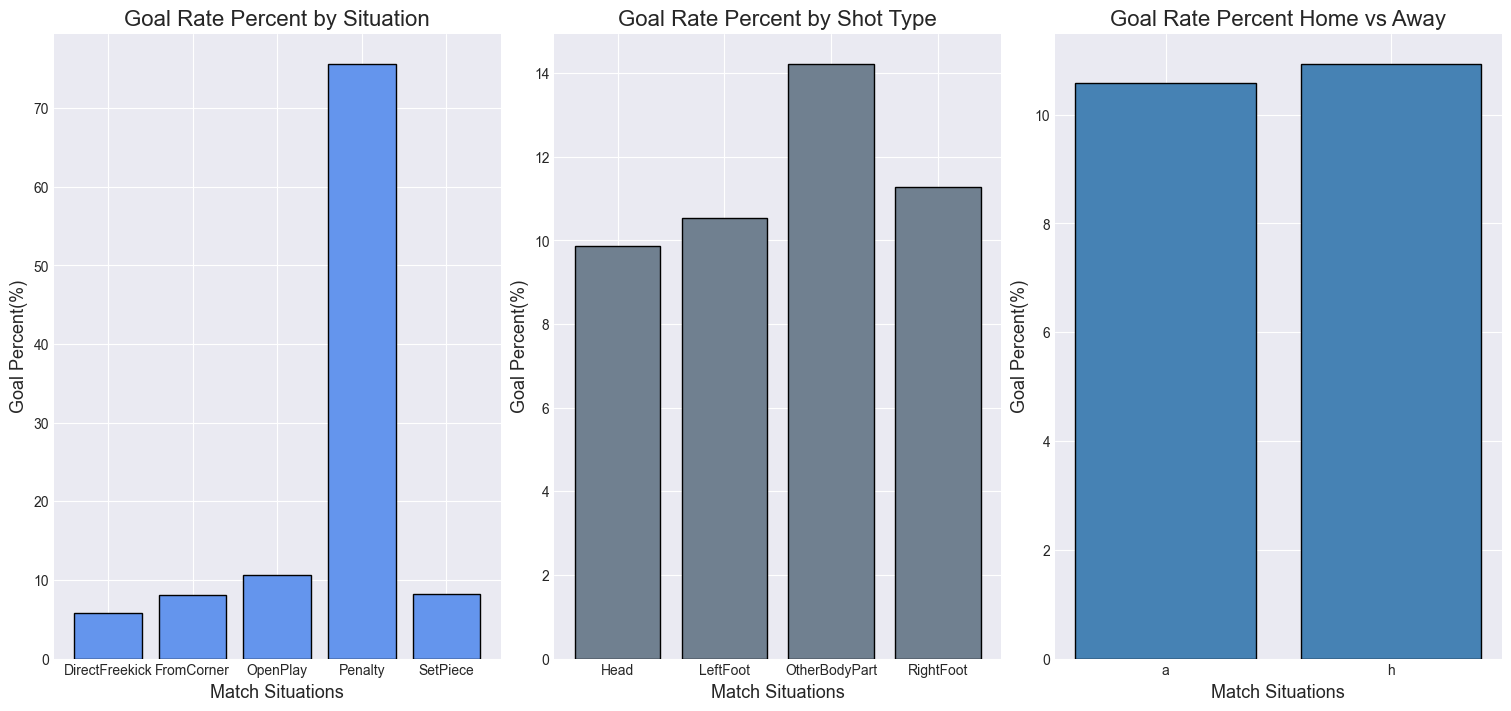

In [102]:
# goal conversion rates for: 'situation', 'shotType', and 'h_a'
# goals scored/ total shots of that type

situation_conv = df.groupby(['result', 'situation']).size().reset_index()
situation_conv.rename(columns = {0: 'goal_count'}, inplace= True)
situation_conv['total_shots'] = situation_conv.groupby('situation')['goal_count'].transform('sum')
situation_conv = situation_conv[situation_conv['result'] == 'Goal']
situation_conv['goal_rate_percent'] = ((situation_conv['goal_count']/situation_conv['total_shots'])*100).round(2)
situation_conv.drop(columns = ['result', 'goal_count'], inplace = True)

shot_conv = df.groupby(['result', 'shotType']).size().reset_index()
shot_conv.rename(columns = {0: 'goal_count'}, inplace= True)
shot_conv['total_shots'] = shot_conv.groupby('shotType')['goal_count'].transform('sum')
shot_conv = shot_conv[shot_conv['result'] == 'Goal']
shot_conv['goal_rate_percent'] = ((shot_conv['goal_count']/shot_conv['total_shots'])*100).round(2)
shot_conv.drop(columns = ['result', 'goal_count'], inplace = True)

h_a_conv = df.groupby(['result', 'h_a']).size().reset_index()
h_a_conv.rename(columns = {0: 'goal_count'}, inplace= True)
h_a_conv['total_shots'] = h_a_conv.groupby('h_a')['goal_count'].transform('sum')
h_a_conv = h_a_conv[h_a_conv['result'] == 'Goal']
h_a_conv['goal_rate_percent'] = ((h_a_conv['goal_count']/h_a_conv['total_shots'])*100).round(2)
h_a_conv.drop(columns = ['result', 'goal_count'], inplace = True)


fig, axs = plt.subplots(ncols=3, nrows=1, figsize=(15, 7), layout="constrained")

axs[0].bar(x = situation_conv['situation'], height = situation_conv['goal_rate_percent'], edgecolor='black', facecolor = 'cornflowerblue')
axs[0].set_title('Goal Rate Percent by Situation', fontsize= 16)
axs[0].set_xlabel('Match Situations', fontsize= 13)
axs[0].set_ylabel('Goal Percent(%)', fontsize= 13)
axs[0].get_yaxis().set_major_formatter(mt.ticker.FuncFormatter(lambda x, p: format(int(x), ',')))

axs[1].bar(x = shot_conv['shotType'], height = shot_conv['goal_rate_percent'], edgecolor='black', facecolor = 'slategrey')
axs[1].set_title('Goal Rate Percent by Shot Type', fontsize= 16)
axs[1].set_xlabel('Match Situations', fontsize= 13)
axs[1].set_ylabel('Goal Percent(%)', fontsize= 13)
axs[1].get_yaxis().set_major_formatter(mt.ticker.FuncFormatter(lambda x, p: format(int(x), ',')))

axs[2].bar(x = h_a_conv['h_a'], height = h_a_conv['goal_rate_percent'], edgecolor='black', facecolor = 'steelblue')
axs[2].set_title('Goal Rate Percent Home vs Away', fontsize= 16)
axs[2].set_xlabel('Match Situations', fontsize= 13)
axs[2].set_ylabel('Goal Percent(%)', fontsize= 13)
axs[2].get_yaxis().set_major_formatter(mt.ticker.FuncFormatter(lambda x, p: format(int(x), ',')))

### 2.6 Player Analysis (10 points)

Analyze the players' performance by calculating the following:
1. How many total matches are present in the dataset? (5 points)
2. How many total matches were played in each season? (5 points)
3. Which 3 players played the most matches in each season? (5 points)
4. How many matches did each player play and show the top 10 players? (5 points)
5. How many goals were scored by each player and show the top 10 players? (5 points)
6. Calculate the average number of goals per game for each player and show the top 10 players who played at least 300 matches. (5 points)


In [103]:
# 1) total matches in dataset
print(f"Total Matches in dataset: {df['match_id'].count():,d}")

Total Matches in dataset: 72,116


In [104]:
# 2) total matches each season
total_match_s = df.groupby(['season']).agg({'match_id': 'count'}).reset_index()
total_match_s.rename(columns = {'match_id': 'count_matches'}, inplace= True)
total_match_s.head(10)

,season,count_matches
0,2015,7314
1,2016,7358
2,2017,7294
3,2018,7419
4,2019,6895
5,2020,6487
6,2021,7098
7,2022,7521
8,2023,7469
9,2024,7261


In [105]:
# 3) 3 players with most matches

player_g = df.groupby(['player_id', 'player']).size().reset_index()
player_g.rename(columns = {0: 'shot_count'}, inplace= True)
player_g.sort_values('shot_count', ascending=False, inplace= True)
player_g.drop(columns = ['player_id'], inplace= True)
player_g.head(3)


,player,shot_count
212,Lionel Messi,839
455,Karim Benzema,656
366,Antoine Griezmann,621


In [106]:
# 4) How many shots did each player make and show the top 10 players

player_g.head(10)


,player,shot_count
212,Lionel Messi,839
455,Karim Benzema,656
366,Antoine Griezmann,621
384,Iago Aspas,593
213,Luis Suárez,591
482,Iñaki Williams,573
232,Gerard Moreno,541
483,Raúl García,451
456,Cristiano Ronaldo,442
772,Kike García,418


In [107]:
# 5) How many goals were scored by each player and show the top 10 players?

tot_goals = df.groupby(['player_id', 'player', 'result']).size().reset_index()
tot_goals.rename(columns = {0: 'goal_count'}, inplace= True)
tot_goals.sort_values('goal_count', ascending=False, inplace= True)
tot_goals = tot_goals[tot_goals['result'] == 'Goal']
tot_goals.drop(columns = ['result', 'player_id'], inplace= True)
tot_goals.head(10)

,player,goal_count
832,Lionel Messi,142
837,Luis Suárez,138
1838,Karim Benzema,130
1557,Iago Aspas,117
1470,Antoine Griezmann,104
917,Gerard Moreno,94
1314,Mikel Oyarzabal,69
1843,Cristiano Ronaldo,65
1805,Willian José,65
1951,Iñaki Williams,64


In [108]:
# 6) Calculate the average number of goals per game for each player and show the top 10 players who played at least 100 matches.
# use player_id, not player name, map ID to name

m_goals = df.groupby(['match_id', 'result']).size().reset_index()
m_goals.rename(columns = {0: 'goal_count'}, inplace= True)
m_goals.sort_values('goal_count', ascending=False, inplace= True)
m_goals = m_goals[m_goals['result'] == 'Goal']
m_goals.drop(columns = ['result'], inplace= True)
m_goals.head(10)

,match_id,goal_count
641,1553,12
1624,1783,9
1406,1731,8
6067,10250,8
3953,8053,8
13024,22743,7
7176,12199,7
12084,19181,7
2994,4055,7
5451,10104,7


### 2.7 Feature Engineering for Analysis (5 points)

You may want to perform some feature engineering to create new features that will be useful for modeling.

Create derived features that will be useful for modeling. (10 points)


In [109]:
import sklearn.metrics as metrics
from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.mixture import GaussianMixture
from sklearn.datasets import make_blobs, make_moons
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA
import math
from math import acos, degrees

In [110]:
# save and clean variables

# kmeans data: I want to evaulate distance and situation, all are from goals
k_data = df.groupby(['player_id', 'X', 'Y', 'result']).size().reset_index()
k_data.rename(columns = {0: 'count'}, inplace = True)
k_data.drop(columns = 'count', inplace = True)

k_data['goal_bin'] = k_data['result'].apply(lambda x: 1 if x == 'Goal' else 0)
k_data['total_goals'] = k_data.groupby('player_id')['goal_bin'].transform('sum')
k_data['total_shots'] = k_data.groupby('player_id')['player_id'].transform('count')

k_data['goal_perc'] = k_data['total_goals']/ k_data['total_shots']

k_data['avg_X'] = k_data.groupby('X')['X'].transform('mean')
k_data['avg_Y'] = k_data.groupby('Y')['Y'].transform('mean')

k_data_X = k_data[k_data['goal_bin'] == 1]
k_data_X = k_data_X.groupby(['goal_perc', 'avg_X', 'avg_Y']).size().reset_index()
k_data_X= k_data_X[['goal_perc', 'avg_X', 'avg_Y']]

k_data_X.head()

,goal_perc,avg_X,avg_Y
0,0.0115,0.8800,0.3610
1,0.0116,0.9630,0.5490
2,0.0154,0.8170,0.5610
3,0.0154,0.9640,0.4730
4,0.0156,0.8850,0.5000


In [111]:
# regression model

# importing/ carrying through id and result but not in model
# calculating a distance and angle of the shot
def sam_reg_model(df):
    r_data = df.groupby(['X', 'Y', 'minute', 'shotType', 'id']).size().reset_index()
    r_data.rename(columns = {0: 'count'}, inplace = True)
    r_data.drop(columns = 'count', inplace = True)

    r_data['shot_bin'] = r_data['shotType'].apply(lambda x: pd.factorize(x)[0].sum())

    r_data['dist'] = r_data.apply(lambda x: math.sqrt(x['X']*2 + x['Y']*2), axis = 1)
    r_data['angle'] = r_data.apply(lambda y: round(math.degrees(math.acos(y['Y']/ y['dist'])), 2), axis = 1)
    
    r_results = r_data['id']
    r_data.drop(columns = ['shotType', 'id'],  inplace = True)

    return r_data, r_results

### 2.8 Correlation Analysis (10 points)

Calcuate and display the correlation matrix of the numerical features and display as a heatmap. (10 points)

               id  minute       X       Y  player_id  season  match_id  \
id         1.0000  0.0206  0.0164 -0.0067     0.5351  0.9939    0.9868   
minute     0.0206  1.0000  0.0193 -0.0030     0.0265  0.0211    0.0204   
X          0.0164  0.0193  1.0000 -0.0123    -0.0018  0.0156    0.0157   
Y         -0.0067 -0.0030 -0.0123  1.0000    -0.0072 -0.0069   -0.0077   
player_id  0.5351  0.0265 -0.0018 -0.0072     1.0000  0.5397    0.5406   
season     0.9939  0.0211  0.0156 -0.0069     0.5397  1.0000    0.9942   
match_id   0.9868  0.0204  0.0157 -0.0077     0.5406  0.9942    1.0000   
h_goals   -0.0491 -0.0138  0.0261  0.0017    -0.0321 -0.0490   -0.0494   
a_goals   -0.0250  0.0000  0.0299 -0.0039    -0.0109 -0.0219   -0.0212   

           h_goals  a_goals  
id         -0.0491  -0.0250  
minute     -0.0138   0.0000  
X           0.0261   0.0299  
Y           0.0017  -0.0039  
player_id  -0.0321  -0.0109  
season     -0.0490  -0.0219  
match_id   -0.0494  -0.0212  
h_goals     1.0000 

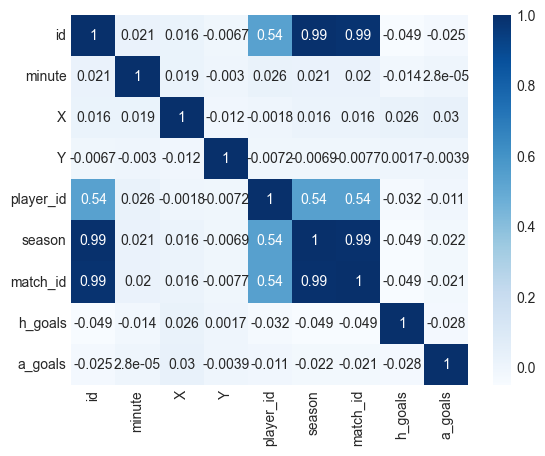

In [112]:
# calculate and display correltion matrix
matrix = df.corr(numeric_only=True)
print(matrix)
sns.heatmap(matrix, cmap="Blues", annot=True)
plt.show()

---

## 3. Clustering Analysis: Player Shooting Archetypes (40 total points)

Identify different types of goal scorers based on their shooting patterns.

Perform K-Means clustering on the player-level statistics. (15 points)
 * Use Silhouette Score to determine the optimal number of clusters.
 * Print a table of the cluster centers.

Based on the cluster centers, assign interpretable names to the clusters. (5 points)
  * These could be for example:
    * Penalty Specialists
    * Aerial Specialists
    * Poachers (Close-range)
    * Long-range Shooters
    * Mixed Style
  * Justify your choices.

Display the results in a table with columns 'Cluster', 'Archetype', 'Total Players', and 'Players'. (10 points)

Visualize the clusters using PCA. (10 points)



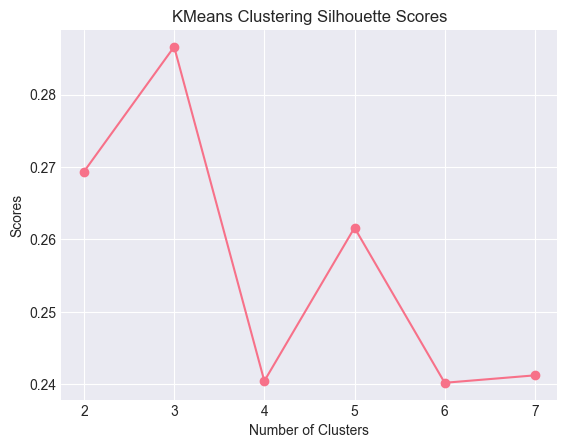

In [113]:
# calculate the clusters 

def silhouette_clusts(X, max):
    sils = np.zeros(max+1)
    sils[0] = 0
    sils[1] = 0
    for k in range(2, max+1):
        kmeans = KMeans(n_clusters = k, random_state=42)
        kmeans.fit_predict(X)
        sils[k] = metrics.silhouette_score(X, kmeans.labels_, metric = 'euclidean')
    return sils

sils = silhouette_clusts(k_data_X, 7)
plt.plot(range(2, len(sils)), sils[2:], 'o-')
plt.xlabel('Number of Clusters')
plt.title('KMeans Clustering Silhouette Scores')
plt.ylabel('Scores')
plt.show()


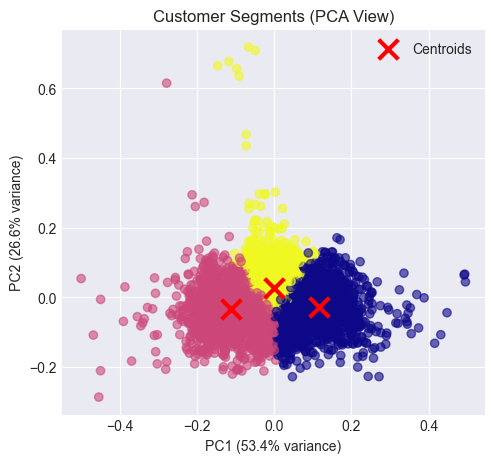

In [114]:
# create clusters
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(k_data_X)

# Visualize clusters in 2D using PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(k_data_X)
C_pca = pca.transform(kmeans.cluster_centers_)


plt.figure(figsize=(12, 5))

# Plot 1: PCA visualization
plt.subplot(1, 2, 1)
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans.labels_, cmap='plasma', alpha=0.6)
plt.scatter(C_pca[:, 0], C_pca[:, 1], 
            c='red', marker='x', s=200, linewidths=3, label='Centroids')
plt.title('Customer Segments (PCA View)')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
plt.legend()

---
## 4. Predictive Modeling: Goal Probability Prediction (50 total points + up to 15 bonus points)

Now we'll build models to predict the probability of scoring a goal.
We'll then compare our model predictions with the actual xG values.

Define and train the following models:
1. Logistic Regression (25 points)
2. Random Forest (25 points)
3. Bonus Models (feel free to use any model you want)  (**Bonus:** 15 points)


Evaluate each model using the following metrics and display the results in a table:
* Accuracy
* Precision
* Recall
* F1-Score
* ROC-AUC




### 4.2 Model 1: Logistic Regression (Baseline)

In [129]:
# logistic regression on location based goal percentage
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.model_selection import train_test_split

# split into two to train
r_data, r_results = sam_reg_model(df)

r_res_result = pd.merge(r_results, df, on='id', how='inner')
r_res_result['goal_bin'] = r_res_result.apply(lambda x: 1 if x['result'] == 'Goal' else 0, axis = 1)

a_train, a_test, b_train, b_test = train_test_split(r_data, r_res_result['goal_bin'], test_size=0.20 ,random_state=42)

# scale data
scaler = MinMaxScaler() 

# make copies for later
a_train_copy = a_train.copy()
a_test_copy = a_test.copy()
b_train_copy = b_train.copy()
b_test_copy = b_test.copy()

a_train_scaled = scaler.fit_transform(a_train_copy)
a_test_scaled = scaler.transform(a_test_copy)

# run model
r_model = LogisticRegression()
r_model.fit(a_train_scaled, b_train_copy)

# evaluation: display results in table? 
reg_eval = {}
y_modeled = r_model.predict(a_test_copy)
reg_acc = accuracy_score(b_test_copy, y_modeled)
reg_prec = precision_score(b_test_copy, y_modeled, average= 'weighted')
reg_recall= recall_score(b_test_copy, y_modeled, average= 'weighted')
reg_f1= f1_score(b_test_copy, y_modeled, average= 'weighted')
reg_rocauc1= roc_auc_score(b_test_copy, y_modeled, average = None)

reg_eval['Acc_Score'] = reg_acc
reg_eval['Precision'] = reg_prec
reg_eval['Recall'] = reg_recall
reg_eval['F1-Score'] = reg_f1
reg_eval['ROC-AUC'] = reg_rocauc1

reg_eval_df = pd.DataFrame({'Evaluation': reg_eval.keys(), 'Score': reg_eval.values()})
reg_eval_df.head()

,Evaluation,Score
0,Acc_Score,0.8910
1,Precision,0.7939
2,Recall,0.8910
3,F1-Score,0.8397
4,ROC-AUC,0.5000


### 4.3 Model 2: Random Forest Classifier

In [130]:
# random forest testing
from sklearn.ensemble import RandomForestClassifier

mytree = RandomForestClassifier(n_estimators=100, random_state=42)
mytree.fit(a_train, b_train)
t_pred = mytree.predict(a_test)

# evaluate
tree_eval = {}
tree_acc_score = accuracy_score(b_test, t_pred)
reg_acc = accuracy_score(b_test, t_pred)
reg_prec = precision_score(b_test, t_pred, average= 'weighted')
reg_recall= recall_score(b_test, t_pred, average= 'weighted')
reg_f1= f1_score(b_test, t_pred, average= 'weighted')
reg_rocauc= roc_auc_score(b_test, t_pred, average = None)

tree_eval['Acc_Score'] = reg_acc
tree_eval['Precision'] = reg_prec
tree_eval['Recall'] = reg_recall
tree_eval['F1-Score'] = reg_f1
tree_eval['ROC-AUC'] = reg_rocauc

tree_eval_df = pd.DataFrame({'Evaluation': tree_eval.keys(), 'Score': tree_eval.values()})
tree_eval_df.head()

,Evaluation,Score
0,Acc_Score,0.8952
1,Precision,0.8715
2,Recall,0.8952
3,F1-Score,0.8745
4,ROC-AUC,0.5981


---

## 5. Model Comparison and Analysis (30 total points)

Create a grouped bar plot to compare each of those metrics across all models. (10 points)

Plot the ROC curves for all models. (10 points)

Plot the confusion matrices for all models. (10 points)


### 5.1 Grouped Bar Plot Comparison

Text(0.5, 1.0, 'Random Forest Evaluation')

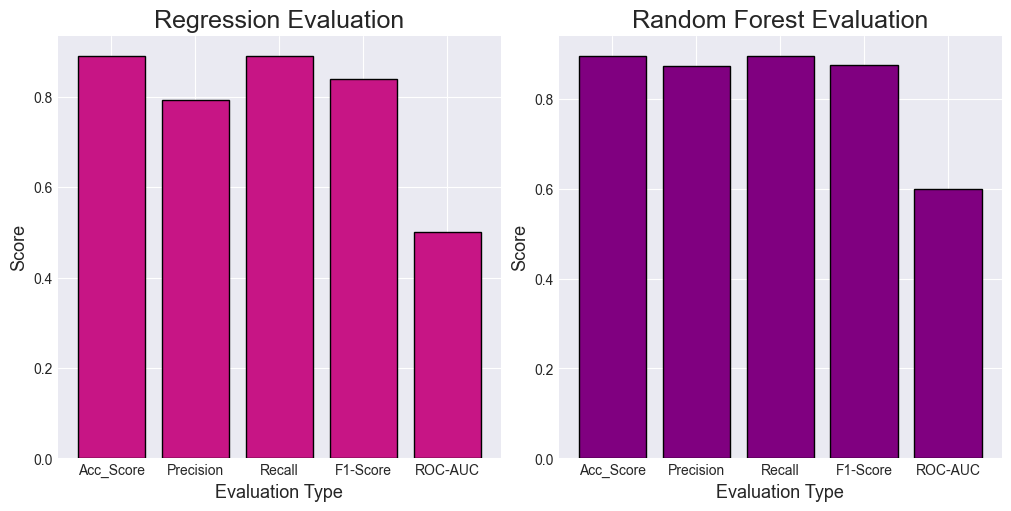

In [131]:
# regression and forest
fig, axs = plt.subplots(ncols=2, nrows=1, figsize=(10, 5), layout="constrained")

axs[0].bar(reg_eval_df['Evaluation'], reg_eval_df['Score'], facecolor = 'mediumvioletred', edgecolor='black')
axs[0].set_xlabel('Evaluation Type', fontsize=13)
axs[0].set_ylabel('Score', fontsize=13)
axs[0].set_title('Regression Evaluation', fontsize=18)

axs[1].bar(tree_eval_df['Evaluation'], tree_eval_df['Score'], facecolor = 'purple', edgecolor='black')
axs[1].set_xlabel('Evaluation Type', fontsize=13)
axs[1].set_ylabel('Score', fontsize=13)
axs[1].set_title('Random Forest Evaluation', fontsize=18)

### 5.2 ROC Curves Comparison

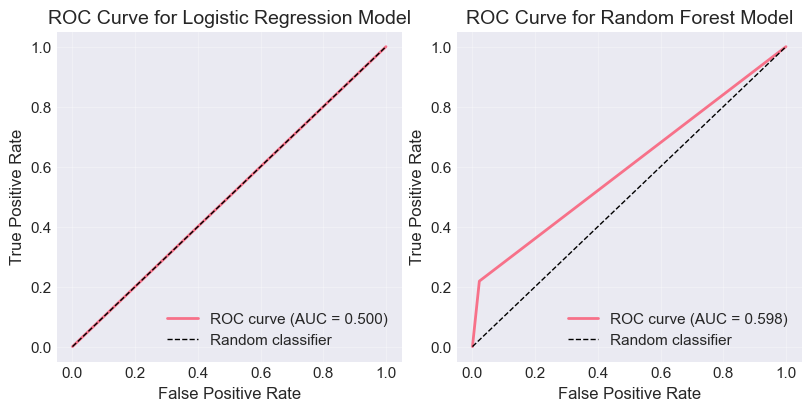

AUC Score: 0.5981


In [139]:
# Compute ROC curve and AUC
fig, axs = plt.subplots(ncols=2, nrows=1, figsize=(8, 4), layout="constrained")

fpr1, tpr1, thresholds1 = metrics.roc_curve(b_test_copy, y_modeled)
fpr2, tpr2, thresholds2 = metrics.roc_curve(b_test, t_pred)

# Plot log reg ROC curve
axs[0].plot(fpr1, tpr1, linewidth=2, label=f'ROC curve (AUC = {reg_rocauc1:.3f})')
axs[0].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random classifier')
axs[0].set_xlabel('False Positive Rate', fontsize=12)
axs[0].set_ylabel('True Positive Rate', fontsize=12)
axs[0].set_title('ROC Curve for Logistic Regression Model', fontsize=14)
axs[0].legend(loc='lower right', fontsize=11)
axs[0].grid(True, alpha=0.3)
axs[0].tick_params(labelsize=11)

# Plot forest ROC curve
axs[1].plot(fpr2, tpr2, linewidth=2, label=f'ROC curve (AUC = {reg_rocauc:.3f})')
axs[1].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random classifier')
axs[1].set_xlabel('False Positive Rate', fontsize=12)
axs[1].set_ylabel('True Positive Rate', fontsize=12)
axs[1].set_title('ROC Curve for Random Forest Model', fontsize=14)
axs[1].legend(loc='lower right', fontsize=11)
axs[1].grid(True, alpha=0.3)
axs[1].tick_params(labelsize=11)
plt.show()

print(f"AUC Score: {reg_rocauc:.4f}")

### 5.3 Confusion Matrices Visualization

In [ ]:
# regression and forest



---

## 6.0 Kaggle Submission (15 total points + up to 10 bonus points)

### Prepare a submission for the Kaggle competition.

1. Load the test dataset, laliga_shots_test_no_result.csv
2. Preprocess the test dataset in the same way you did for the training dataset.
3. Make predictions for the test dataset using your best model.
4. Create a submission file and upload it to Kaggle.

The submission file should be a csv file with the following columns:

| is_goal | goal_prob |
|---------|-----------|
| 0       | 0.234      |
| 1       | 0.634       |
| 0       | 0.142     |

We will evaluate using F1-score.


The top 10 finishers get an additional 10 bonus points.

The 11-20 finishers get an additional 5 bonus points.




In [ ]:
# kaggle submission prep

# load dataset
test_df = pd.read_csv('laliga_shots_test_no_result.csv')

# get columns for my model
reg_test_data, test_vars = sam_reg_model(test_df)

# scale
test_scaled = scaler.fit_transform(reg_test_data)

# run regression model
final1 = r_model.predict_proba(test_scaled)[:, 1]
id = test_vars

# run random forest
final2 = mytree.predict_proba(test_scaled)[:, 1]

In [ ]:
# create submission
results = pd.DataFrame({ 'id': id, 'goal_prob': final1})
results.to_csv(r"kaggle_submission.csv", index=False)

results1 = pd.DataFrame({ 'id': id, 'goal_prob': final2})
results1.to_csv(r"kaggle_submission1.csv", index=False)

---
## 7. Summary and Conclusions (10 points)

Summaryize your findings and conclusions. (10 points)

Among other things, answer the following questions:
* What did you learn from this analysis?
* Were there any unexpected findings?
* What would you do differently if you had more time?


---

In [ ]:
# can do extra visuals for something specific: a specific player, etc
# npm soccer? 

# write what we found etc. 

# id and y_probar for kaggle submission? 